# 🧬 Breast Cancer Risk Analysis & Classification

This project aims to analyze breast cancer diagnostic data and develop models to support decision-making in a biomedical context.

We explore:
- Rule-based risk classification
- Model limitations
- Logistic regression for improved prediction

🎯 Goal: Improve early detection while understanding trade-offs between false positives and false negatives.

IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 📊 Data Understanding

- diagnosis: target variable (B = benign, M = malignant)
- Features represent tumor characteristics (radius, area, concavity, etc.)

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## 🧩 LIMPEZA DE DADOS



*   Remove unnecessary columns (id, Unnamed: 32)
*   Convert target variable ('B': 0, 'M': 1)
* Check for missing and duplicate values



In [4]:
df = df.drop(columns=["id", "Unnamed: 32"])
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [7]:
df.duplicated().sum()

np.int64(0)

## 🔭 Exploratory Analysis



*   Distribution of the target variable
*   Comparison of variables



/tmp/ipykernel_159/117125529.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette=['skyblue', 'salmon'])


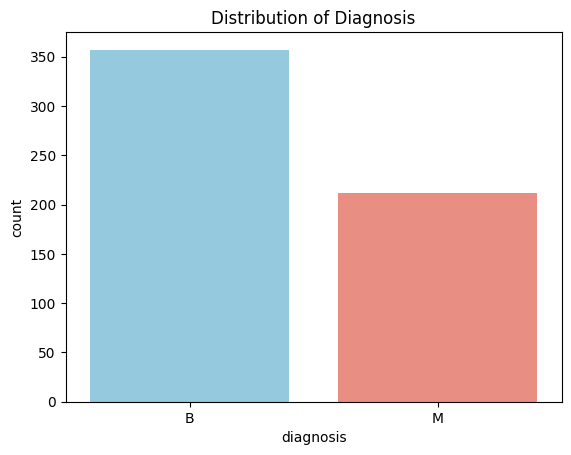

In [8]:
sns.countplot(x="diagnosis", data=df, palette=['skyblue', 'salmon'])
plt.title("Distribution of Diagnosis")
plt.xticks([0, 1], ['B', 'M'])
plt.show()

/tmp/ipykernel_159/1867170263.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="diagnosis", y="radius_mean", data=df, palette=['skyblue', 'salmon'])


([<matplotlib.axis.XTick at 0x78bdb8d7a090>,
 [Text(0, 0, 'B'), Text(1, 0, 'M')])

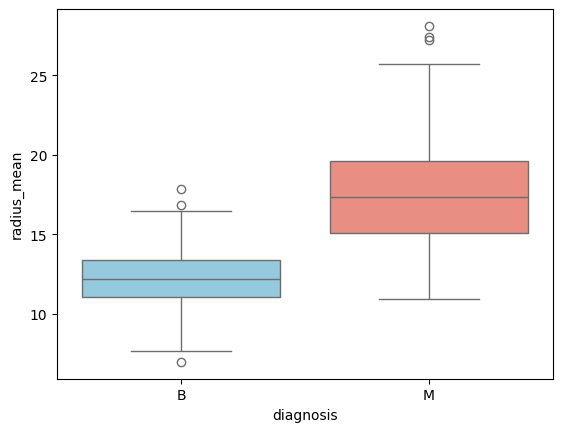

In [9]:
sns.boxplot(x="diagnosis", y="radius_mean", data=df, palette=['skyblue', 'salmon'])
plt.xticks([0, 1], ['B', 'M'])

## ⚙️ Rule-Based Risk Model

Initial approach using simple thresholds.



* Simulate a simple decision
* Understand the limitations




In [10]:
df["risk_level"] = df["radius_mean"].apply(
    lambda x: 1 if x > 15 else 0
)

pd.crosstab(df["risk_level"], df["diagnosis"])

diagnosis,0,1
risk_level,,
0,345,51
1,12,161


⚠️ Limitation:
This approach fails due to overlapping distributions between benign and malignant cases.

## 🔧 Feature Combination Approach



* Combine relevant variables
* Create a more robust score



In [11]:
df["risk_score"] = (
    df["radius_mean"] * 0.3 +
    df["area_mean"] * 0.3 +
    df["concavity_mean"] * 0.2 +
    df["concave points_mean"] * 0.2
)

In [12]:
threshold = df["risk_score"].quantile(0.6)

df["risk_level"] = (df["risk_score"] > threshold).astype(int)
pd.crosstab(df["risk_level"], df["diagnosis"])

diagnosis,0,1
risk_level,,
0,309,32
1,48,180


Despite improvements, the model still showed imbalance and sensitivity issues.



## 🚧 Model Limitation

Rule-based approaches were not sufficient to separate the classes effectively.

A logistic regression model was implemented



*   Separation of variables
*   Train a model
* Predict



In [13]:
X = df[[
    "radius_mean",
    "area_mean",
    "concavity_mean",
    "concave points_mean"
]]

y = df["diagnosis"]

model = LogisticRegression()
model.fit(X, y)

y_pred = model.predict(X)

[[344  13]
 [ 44 168]]


Text(0.5, 1.0, 'Confusion Matrix')

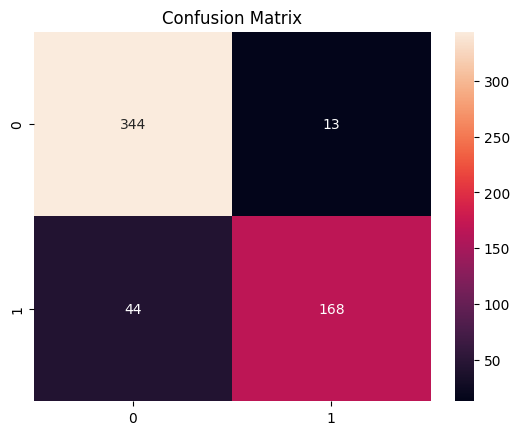

In [14]:
cm = confusion_matrix(y, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")

In [15]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92       357
           1       0.93      0.79      0.85       212

    accuracy                           0.90       569
   macro avg       0.91      0.88      0.89       569
weighted avg       0.90      0.90      0.90       569



## 📊 Model Evaluation

- False Negatives: 44 → missed malignant cases
- False Positives: 13 → unnecessary alerts

The model improved precision significantly while maintaining acceptable sensitivity.

In [16]:
y_prob = model.predict_proba(X)[:,1]

df["risk_level"] = (y_prob > 0.2).astype(int)
pd.crosstab(df["risk_level"], df["diagnosis"])

diagnosis,0,1
risk_level,,
0,290,17
1,67,195


In [17]:
y_prob = model.predict_proba(X)[:,1]

df["risk_level"] = (y_prob > 0.6).astype(int)
pd.crosstab(df["risk_level"], df["diagnosis"])


diagnosis,0,1
risk_level,,
0,349,55
1,8,157


Lowering the threshold to 0.2 significantly increased the model’s sensitivity (recall ≈ 0.92), substantially reducing false negatives.

Despite the increase in false positives, this trade-off may be acceptable in a medical context, where it is preferable to investigate suspected cases rather than fail to diagnose patients with the disease.

However, it may also be considered a delicate approach given the increased costs associated with further investigation.

## 🚀 Conclusion

- Rule-based models are limited in complex biomedical data
- Logistic regression improves classification balance
- Trade-offs are essential in decision-making

💡 This project highlights the importance of aligning models with real-world impact.

In [20]:
from google.colab import files

df.to_csv('cance_data.csv', index=False)
files.download('cance_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from pandas.io import sql
print(sql.get_schema(df, 'cancer_data'))


CREATE TABLE "cancer_data" (
"diagnosis" INTEGER,
  "radius_mean" REAL,
  "texture_mean" REAL,
  "perimeter_mean" REAL,
  "area_mean" REAL,
  "smoothness_mean" REAL,
  "compactness_mean" REAL,
  "concavity_mean" REAL,
  "concave points_mean" REAL,
  "symmetry_mean" REAL,
  "fractal_dimension_mean" REAL,
  "radius_se" REAL,
  "texture_se" REAL,
  "perimeter_se" REAL,
  "area_se" REAL,
  "smoothness_se" REAL,
  "compactness_se" REAL,
  "concavity_se" REAL,
  "concave points_se" REAL,
  "symmetry_se" REAL,
  "fractal_dimension_se" REAL,
  "radius_worst" REAL,
  "texture_worst" REAL,
  "perimeter_worst" REAL,
  "area_worst" REAL,
  "smoothness_worst" REAL,
  "compactness_worst" REAL,
  "concavity_worst" REAL,
  "concave points_worst" REAL,
  "symmetry_worst" REAL,
  "fractal_dimension_worst" REAL,
  "risk_level" INTEGER,
  "risk_score" REAL
)


In [29]:
df_cancer = df.copy()

df_cancer["probability"] = model.predict_proba(X)[:,1]

df_cancer.to_csv("df_cancer.csv", index=False)